In [60]:
using Random, GMRF

include("src/dataGen.jl");
include("src/cavi.jl");
include("src/mcmc.jl");
include("src/plotting.jl");

Taille de la grille (à ne pas modifier)

In [76]:
M₂ = 20;
M₁ = 20;
M = M₁ * M₂;

- Génération de la grille cible
- Création des données artificielles

In [125]:
Random.seed!(300);
Fmu = iGMRF(M₁, M₂, 1, 10);
Fphi = iGMRF(M₁, M₂, 1, 100);
gridTarget = generateTargetGrid(Fmu, Fphi);
gridTarget[:, :, 1] = gridTarget[:, :, 1] .+ 10.0;
gridTarget[:, :, 2] = gridTarget[:, :, 2] .+ 1.0;
gridTarget[:, :, 3] = gridTarget[:, :, 3] .+ .1;
nobs = 100;
data = generateData(gridTarget, nobs);

# CAVI

In [136]:
nEpoch = 20;
epochSize = 2;

initialValues = Dict(
    :μ => zeros(M),
    :ϕ => zeros(M),
    :ξ => 0.0,
    :kappaUparam => ((M - 1) / 2 + 1) / 1,
    :kappaVparam => ((M - 1) / 2 + 1) / 1,
);

spatialScheme = Dict(
    :M => M,
    :Fmu => Fmu,
    :Fphi => Fphi,
    :data => data,
);

In [137]:
include("src/cavi.jl");

res = runCAVI(nEpoch, epochSize, initialValues, spatialScheme);

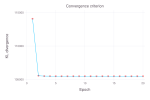

In [138]:
plotConvergenceCriterion(res.MCKL)

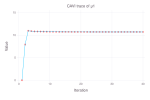

In [131]:
plotTraceCAVI(res.traces[:muMean][1, :], "μ1")

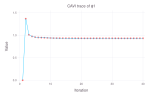

In [132]:
plotTraceCAVI(res.traces[:phiMean][1, :], "ϕ1")

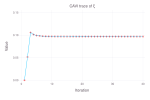

In [133]:
plotTraceCAVI(res.traces[:xiMean], "ξ")

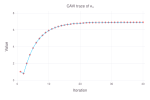

In [134]:
trace = res.traces[:kappaUparams][1, :] ./ res.traces[:kappaUparams][2, :];

plotTraceCAVI(trace, "κᵤ")

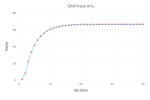

In [135]:
trace = res.traces[:kappaVparams][1, :] ./ res.traces[:kappaVparams][2, :];

plotTraceCAVI(trace, "κᵥ")

# MCMC

In [109]:
datastructure = Dict(
    :Y => data,
    :Fmu => Fmu,
    :Fphi => Fphi,
);

niter = 10000;

initialvalues = Dict(
    :μ => zeros(M),
    :ϕ => zeros(M),
    :ξ => .2,
    :κᵤ => 1.0,
    :κᵥ => 1.0,
);

stepsize = Dict(
    :μ => .65,
    :ϕ => .25,
    :ξ => .02,
);

In [110]:
include("src/mcmc.jl")

chain = mcmc(datastructure, niter, initialvalues, stepsize);

Progress: 100%|█████████████████████████████████████████| Time: 0:01:16


In [111]:
changerate(chain)

             Change Rate
          μ1       0.308
          μ2       0.272
          μ3       0.265
          μ4       0.262
          μ5       0.284
          μ6       0.281
          μ7       0.272
          μ8       0.281
          μ9       0.278
         μ10       0.293
         μ11       0.267
         μ12       0.284
         μ13       0.278
         μ14       0.286
         μ15       0.275
         μ16       0.279
         μ17       0.275
         μ18       0.291
         μ19       0.277
         μ20       0.328
         μ21       0.253
         μ22       0.247
         μ23       0.251
         μ24       0.260
         μ25       0.246
         μ26       0.255
         μ27       0.257
         μ28       0.254
         μ29       0.256
         μ30       0.262
         μ31       0.252
         μ32       0.264
         μ33       0.249
         μ34       0.263
         μ35       0.257
         μ36       0.267
         μ37       0.261
         μ38       0.263
         μ39       0.263


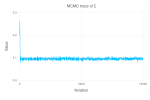

In [112]:
plotTraceMCMC(chain, "ξ")

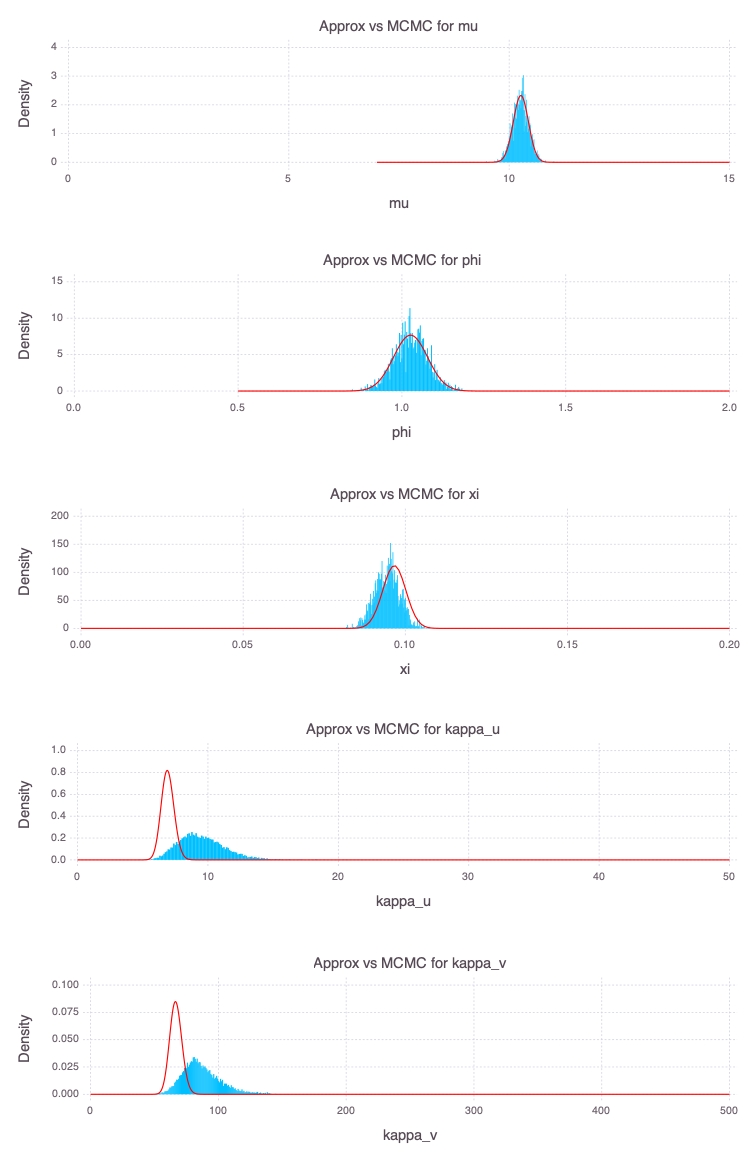

In [140]:
include("src/plotting.jl");

plotCAVIvsMCMC(200, caviRes=res, mcmcChain=chain, warmingSize=1000)

In [93]:
gridTarget[:, :, 1]

20×20 Matrix{Float64}:
 10.7105   10.6276    9.94655   9.76079  …   9.9846    9.98079   9.37703
 10.3086   10.2909    9.98478   9.80647      9.59736   9.99963   9.74784
 10.5544   10.6536   10.2129    9.97366      9.72774   9.76834  10.5027
 10.3813   10.4305   10.1733   10.0024       9.93121  10.0748   10.5201
 10.5198   10.1155   10.2228   10.2223      10.018     9.93589  10.1718
 10.2673   10.1608    9.79129  10.0226   …   9.81122  10.0038    9.4228
 10.0442    9.70586   9.74161   9.69698      9.80007   9.90248   9.86684
  9.83686   9.81915   9.59682   9.69336     10.1607   10.0441    9.74078
 10.0732    9.99672   9.71142   9.49504     10.1646   10.1756    9.86109
  9.88299  10.1672    9.95824  10.0702      10.3189    9.92261  10.2178
  9.79077  10.307    10.1484   10.1818   …  10.2155   10.1778   10.1329
  9.75863   9.95671  10.0587   10.1156      10.2848   10.065    10.2513
  9.99405  10.0895   10.422    10.1687      10.1172   10.0261    9.9827
 10.0252   10.0101   10.1448    9.95

In [30]:
reshape(res.traces[:muMean][:, end], M₁, M₂)'

10×10 adjoint(::Matrix{Float64}) with eltype Float64:
 11.7632   11.7255   10.2272   10.5287   …  10.773    10.2484   10.3336
  9.90624  10.3758    9.96758  10.1311      10.894    10.3513    9.5669
 10.1563   10.3604   10.1188   10.3945      10.1439   10.1569    9.74174
 10.6212   11.1256   10.7717   11.1311      10.202    10.5805    9.13802
 11.2215   10.9932   10.3163    9.9324      10.8521   10.201     9.52411
 10.5149    9.85516   9.67202  10.3819   …  10.8022    9.35041  10.793
 10.6253   10.9135    9.97642   9.31402      9.86283  10.093    10.9552
  9.84768  10.5202    9.75647   8.91675      9.29344   9.61694  10.9851
  9.78487   9.20666   9.20664   9.27606      9.72258   8.93964   9.79796
  7.79273   8.68652   7.91505   7.95143      9.30614   9.32356   9.3816